In [6]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path

In [7]:
# try to plot the test case
experiment_dir = Path("buoy_tracking_data/experiments/experiment_live_20260521_175620")
filename = experiment_dir / "tracking_data_cog.csv"

In [11]:
df = pd.read_csv(filename)

print(f"File: {filename}")
print(f"Rows: {len(df):,}")
print(f"Columns: {len(df.columns)}")

display(df.head())

File: buoy_tracking_data/experiments/experiment_live_20260521_175620/tracking_data_cog.csv
Rows: 760
Columns: 25


,Date,Time,Buoy_ID,LED_On,Ref_Marker_Frame_Detected,CoG_Pos_X_Rel,CoG_Pos_Y_Rel,CoG_Pos_Z_Rel,CoG_Rot_X_Rel_deg,CoG_Rot_Y_Rel_deg,...,CoG_Pos_X_Cam,CoG_Pos_Y_Cam,CoG_Pos_Z_Cam,CoG_Rot_X_Cam_deg,CoG_Rot_Y_Cam_deg,CoG_Rot_Z_Cam_deg,CoG_Quat_X_Cam,CoG_Quat_Y_Cam,CoG_Quat_Z_Cam,CoG_Quat_W_Cam
0,2026-05-21,17:56:23.208,2,1,0,NaN,NaN,NaN,NaN,NaN,...,0.250029,-0.176555,2.028776,-161.706,43.236,12.784,-0.918653,-0.043982,0.377923,0.106376
1,2026-05-21,17:56:23.370,2,1,0,NaN,NaN,NaN,NaN,NaN,...,0.249860,-0.176388,2.028689,-161.589,43.118,12.902,-0.918853,-0.044733,0.377146,0.107092
2,2026-05-21,17:56:23.501,2,1,0,NaN,NaN,NaN,NaN,NaN,...,0.249979,-0.176713,2.029061,-161.624,43.195,12.842,-0.918677,-0.044241,0.377688,0.106897
3,2026-05-21,17:56:23.635,2,1,0,NaN,NaN,NaN,NaN,NaN,...,0.250030,-0.176584,2.028324,-161.726,43.260,12.746,-0.918614,-0.043704,0.378070,0.106306
4,2026-05-21,17:56:23.765,2,1,0,NaN,NaN,NaN,NaN,NaN,...,0.250007,-0.176909,2.030708,-161.648,43.091,12.801,-0.919028,-0.044162,0.376819,0.106985


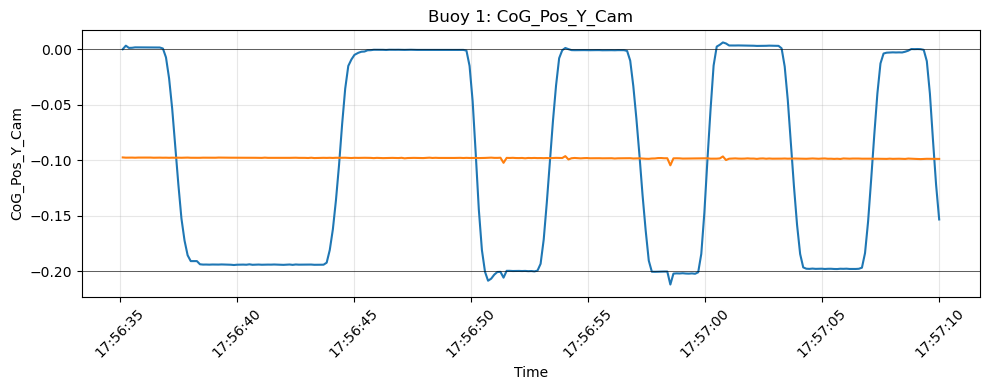

In [50]:
buoy_1 = df[df["Buoy_ID"] == 1].copy()
buoy_1["DateTime"] = pd.to_datetime(buoy_1["Date"] + " " + buoy_1["Time"])

buoy_2 = df[df["Buoy_ID"] == 2].copy()
buoy_2["DateTime"] = pd.to_datetime(buoy_2["Date"] + " " + buoy_2["Time"])

# Edit these to constrain the plot window. Use None for no limit.
start_time = "2026-05-21 17:56:35"
end_time = "2026-05-21 17:57:10"

plot_df_1 = buoy_1.copy()
plot_df_2 = buoy_2.copy()
if start_time is not None:
    plot_df_1 = plot_df_1[plot_df_1["DateTime"] >= pd.to_datetime(start_time)]
    plot_df_2 = plot_df_2[plot_df_2["DateTime"] >= pd.to_datetime(start_time)]
if end_time is not None:
    plot_df_1 = plot_df_1[plot_df_1["DateTime"] <= pd.to_datetime(end_time)]
    plot_df_2 = plot_df_2[plot_df_2["DateTime"] <= pd.to_datetime(end_time)]

# Shift so first value of buoy 1 becomes zero
y0 = plot_df_1["CoG_Pos_Y_Cam"].iloc[0]

plot_df_1["CoG_Pos_Y_Cam_shifted"] = plot_df_1["CoG_Pos_Y_Cam"] - y0
plot_df_2["CoG_Pos_Y_Cam_shifted"] = plot_df_2["CoG_Pos_Y_Cam"] - y0


plt.figure(figsize=(10, 4))
plt.plot(plot_df_1["DateTime"], plot_df_1["CoG_Pos_Y_Cam_shifted"])
plt.plot(plot_df_2["DateTime"], plot_df_2["CoG_Pos_Y_Cam_shifted"])
plt.axhline(0, color='k', linewidth=0.7, alpha=0.6)
plt.axhline(-0.2, color='k', linewidth=0.7, alpha=0.6)
plt.xlabel("Time")
plt.ylabel("CoG_Pos_Y_Cam")
plt.title("Buoy 1: CoG_Pos_Y_Cam")
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()